## Ejercicio 3


--- Entrenando con Tasa de Aprendizaje: 0.01 ---
Capa construida: 4 entradas --> 6 neuronas
Capa construida: 6 entradas --> 3 neuronas


Entrenamiento:   0%|          | 0/300 [00:00<?, ?it/s]

Entrenamiento: 100%|██████████| 300/300 [00:01<00:00, 192.67it/s]


Resultado Test: 34/37 correctos (91.9% de precisión)

--- Entrenando con Tasa de Aprendizaje: 0.1 ---
Capa construida: 4 entradas --> 6 neuronas
Capa construida: 6 entradas --> 3 neuronas


Entrenamiento: 100%|██████████| 300/300 [00:01<00:00, 202.52it/s]


Resultado Test: 36/37 correctos (97.3% de precisión)

--- Entrenando con Tasa de Aprendizaje: 0.2 ---
Capa construida: 4 entradas --> 6 neuronas
Capa construida: 6 entradas --> 3 neuronas


Entrenamiento: 100%|██████████| 300/300 [00:01<00:00, 191.23it/s]


Resultado Test: 37/37 correctos (100.0% de precisión)


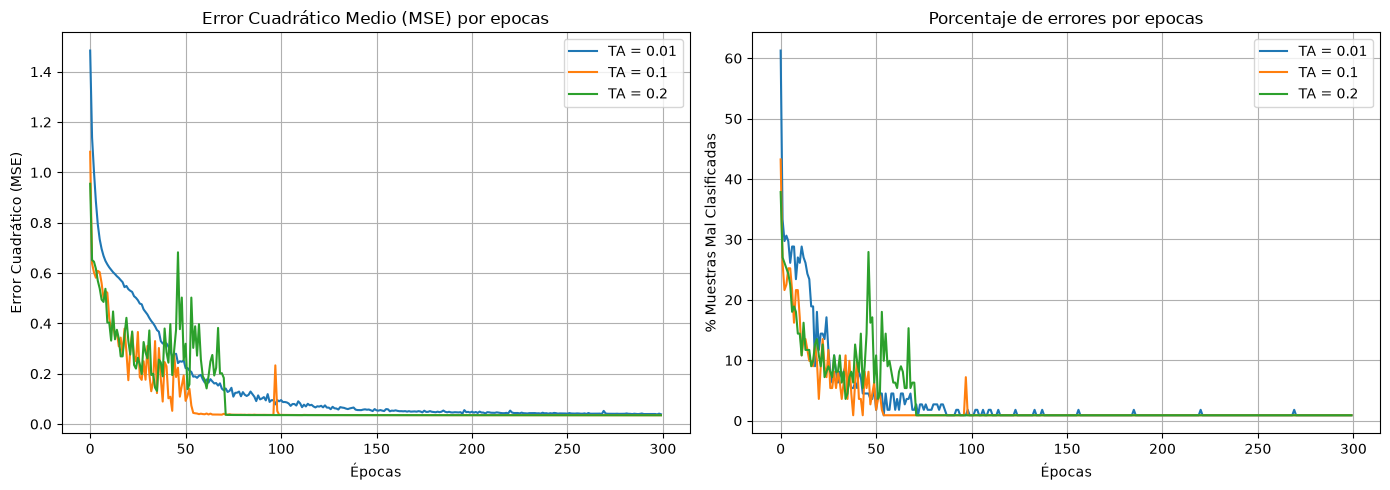

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import csv

class Capa:
    def __init__(self, num_entradas, num_neuronas):
        self.w = np.random.uniform(-0.5, 0.5, (num_entradas+1, num_neuronas))
        self.entrada = None
        self.salida = None

    def activacion_sigmoide(self, z):
        return (1.0 - np.exp(-z)) / (1.0 + np.exp(-z))
        
    def derivada_sigmoide(self, a):
        return 0.5 * (1.0 - a**2)

    def forward(self, entrada): 
        sesgo = np.array([[-1]])
        self.entrada = np.hstack((sesgo, entrada))
        z = np.dot(self.entrada, self.w)
        self.salida = self.activacion_sigmoide(z)
        return self.salida

    def backward(self, gradiente_siguiente, tasa_aprendizaje):
        delta = gradiente_siguiente * self.derivada_sigmoide(self.salida)
        gradiente_hacia_atras = np.dot(delta, self.w[1:, :].T)
        self.w += tasa_aprendizaje * np.dot(self.entrada.T, delta)
        return gradiente_hacia_atras

class RedMulticapa:
    def __init__(self, arquitectura, tasa_aprendizaje=0.1, epocas_maximas=1000, tolerancia_error=0.0):
        self.capas = []  
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas_maximas = epocas_maximas
        self.tolerancia_error = tolerancia_error

        # --- CONSTRUCCION DE LAS CAPAS ---
        for i in range(len(arquitectura) - 1):
            entradas_capa = arquitectura[i]
            neuronas_capa = arquitectura[i+1]
            nueva_capa = Capa(entradas_capa, neuronas_capa)
            self.capas.append(nueva_capa)
            
            print(f"Capa construida: {entradas_capa} entradas --> {neuronas_capa} neuronas")

    def forward_red(self, x):
        salida = x.reshape(1, -1)
        for capa in self.capas:
            salida = capa.forward(salida)
        return salida

    def train(self, X_train, Y_train):
        historico_mse = []
        historico_cls = []

        for epoca in tqdm(range(self.epocas_maximas), desc="Entrenamiento: "):
            error_cuad_total = 0.0
            errores_epoca = 0 

            indices = np.random.permutation(len(X_train))
            X_permut = X_train[indices]
            Y_permut = Y_train[indices]

            for x, yd in zip(X_permut, Y_permut):
                
                yd_matriz =  yd.reshape(1, -1)
                salida_actual = self.forward_red(x)

                gradiente = yd_matriz - salida_actual
                error_cuad_total += 0.5 *np.sum(gradiente**2)

                if np.argmax(salida_actual) != np.argmax(yd_matriz):
                    errores_epoca+=1

                for capa in reversed(self.capas):
                    gradiente = capa.backward(gradiente, self.tasa_aprendizaje)

            mse_epoca = error_cuad_total/len(X_train)
            porcentaje_error = (errores_epoca/len(X_train))*100.0

            historico_mse.append(mse_epoca)
            historico_cls.append(porcentaje_error)

        return historico_mse, historico_cls
    
    def test(self, X_test, Y_test):
        aciertos = 0
        for x, yd in zip(X_test, Y_test):
            salida = self.forward_red(x)
            if np.argmax(salida) == np.argmax(yd):
                aciertos += 1

        precision = (aciertos / len(Y_test))* 100.0
        
        print(f"Resultado Test: {aciertos}/{len(Y_test)} correctos ({precision:.1f}% de precisión)")
        return precision

def cargar_datos(ruta_archivo):
    datos_x = []
    yd = []
    with open(ruta_archivo, 'r') as archivo:
        archivo_csv = csv.reader(archivo)
        for fila in archivo_csv:
            entradas = [float(val) for val in fila[:4]]
            datos_x.append(entradas)

            salidas = [float(val)for val in fila[4:]]
            yd.append(salidas)
    return np.array(datos_x), np.array(yd)


if __name__ == "__main__":
    X_trn, Y_trn = cargar_datos("datos/iris81_trn.csv")
    X_tst, Y_tst = cargar_datos("datos/iris81_tst.csv")

    tasas_aprendizaje = [0.01, 0.10, 0.20]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for TA in tasas_aprendizaje:
        print(f"\n--- Entrenando con Tasa de Aprendizaje: {TA} ---")
        red = RedMulticapa(arquitectura=[4, 6, 3], tasa_aprendizaje=TA, epocas_maximas=300)
        
        historico_mse, historico_cls = red.train(X_trn, Y_trn)
        red.test(X_tst, Y_tst)

        # Grafico Error Cuadratico
        ax1.plot(historico_mse, label=f'TA = {TA}')
        # Grafico Error de Clasificacion
        ax2.plot(historico_cls, label=f'TA = {TA}')

    ax1.set_title("Error Cuadrático Medio (MSE) por epocas")
    ax1.set_xlabel("Épocas")
    ax1.set_ylabel("Error Cuadrático (MSE)")
    ax1.legend()
    ax1.grid(True)

    ax2.set_title("Porcentaje de errores por epocas")
    ax2.set_xlabel("Épocas")
    ax2.set_ylabel("% Muestras Mal Clasificadas")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()